<a href="https://colab.research.google.com/github/Mayar-alsulami/Final_Project/blob/main/02_features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler

df=pd.read_csv('/content/drive/MyDrive/openpowerlifting_cleaned (1).csv')
df.head()

,Age,Sex,Equipment,BodyweightKg,TotalKg
0,47,F,Wraps,59.60,138.35
1,42,F,Single-ply,58.51,401.42
2,42,F,Raw,58.51,95.25
3,18,F,Raw,63.68,122.47
4,28,F,Wraps,62.41,392.36


In [ ]:
#Here, using the one-hot encoding on one column because binary encoding is better for 'Sex' column

# Reload df to ensure 'Equipment' column is present for encoding
# This ensures the cell can be run independently even if df was modified previously
import pandas as pd
df_original = pd.read_csv('/content/drive/MyDrive/openpowerlifting_cleaned (1).csv')

df = pd.get_dummies(df, columns=['Equipment'], drop_first=True)   #This might be long and has new things. Yes because I searched for a method and asked one of my cousins for help because it kept showing non-exsiting errors

# 2. Ensure the new Equipment columns are 0/1 integers
# (This finds any column that starts with 'Equipment_')
equipment_cols = [col for col in df.columns if 'Equipment_' in col] # Corrected 'df_encoded' to 'df'
df[equipment_cols] = df[equipment_cols].astype(int)

# 3. Final verification
print("Columns now in your data:")
print(df.columns.tolist())
df.head()


Columns now in your data:
['Age', 'Sex', 'BodyweightKg', 'TotalKg', 'Equipment_Raw', 'Equipment_Single-ply', 'Equipment_Straps', 'Equipment_Wraps']


,Age,Sex,BodyweightKg,TotalKg,Equipment_Raw,Equipment_Single-ply,Equipment_Straps,Equipment_Wraps
0,47,F,59.60,138.35,0,0,0,1
1,42,F,58.51,401.42,0,1,0,0
2,42,F,58.51,95.25,1,0,0,0
3,18,F,63.68,122.47,1,0,0,0
4,28,F,62.41,392.36,0,0,0,1


In [ ]:
# USED BINARY/ONE-HOT ENCODING BECAUSE NO NEED FOR ORDINAL ENCODING IN THIS DATASET.
# 1. First, let's look at what is actually in the column right now
print(f"Current unique values before fix: {df['Sex'].unique()}")

# 2. Re-map to make sure
# We include 1 and 0 in the mapping so it doesn't break if you run it twice
mapping = {'M': 1, 'F': 0, '1': 1, '0': 0, 1: 1, 0: 0}

# 3. Apply the fix
df['Sex'] = df['Sex'].map(mapping)

# 4. If there are STILL NaNs, it means some rows have weird data and we have to fix it in the first notebook.
# We will fill them with the most common value (usually 1 for Male in this dataset, 0 for females)
# just to prevent the model from crashing, we mode the 0 index
df['Sex'] = df['Sex'].fillna(df['Sex'].mode()[0])

# 5. Force it to be an integer so it doesn't appear in True/False
df['Sex'] = df['Sex'].astype(int)

print(f"Final unique values: {df['Sex'].unique()}")
df.head(100) # Print 100. to make sure it worked as well.

Current unique values before fix: ['F' 'M']
Final unique values: [0 1]


,Age,Sex,BodyweightKg,TotalKg,Equipment_Raw,Equipment_Single-ply,Equipment_Straps,Equipment_Wraps
0,47,0,59.60,138.35,0,0,0,1
1,42,0,58.51,401.42,0,1,0,0
2,42,0,58.51,95.25,1,0,0,0
3,18,0,63.68,122.47,1,0,0,0
4,28,0,62.41,392.36,0,0,0,1
...,...,...,...,...,...,...,...,...
95,20,1,95.03,402.50,1,0,0,0
96,34,1,97.16,600.00,0,0,0,1
97,19,1,99.56,692.50,1,0,0,0
98,19,1,97.98,470.00,1,0,0,0


In [ ]:
import numpy as np

# 1. Why: This measures 'Body Density' or 'Maturity per KG'. It helps
# the model distinguish between a young/heavy athlete (high potential)
# and an older/heavy athlete (different strength curve).
df['Age_Weight_Ratio'] = np.where(
    df['BodyweightKg'] > 0,
    df['Age'] / df['BodyweightKg'],
    0
)

# 2. Feature: Age_Bodyweight_Interaction (Interaction Feature)
# Why: Strength is a product of both mass and physical maturity.
# This tells the model to look at these two variables TOGETHER
# rather than as two separate, unrelated numbers.
df['Age_Bodyweight_Interaction'] = df['Age'] * df['BodyweightKg']

# 3. Feature: Equipment One-Hot Columns (Wraps, Single-ply, etc.)
# Why: This directly answers your goal of seeing how gear affects
# the lift. It allows the model to add a specific 'weight bonus'
# for each type of equipment used compared to 'Raw' lifting.
df['Is_Heavyweight'] = (df['BodyweightKg'] > 90).astype(int)
df['Using_Equipment'] = (df['Equipment_Raw'] == 0).astype(int)

# 3. The Useful Feature: Heavyweight using Equipment
df['Heavyweight_Gear_Boost'] = df['Is_Heavyweight'] * df['Using_Equipment']

# Let's see how it looks
df[['BodyweightKg', 'Equipment_Raw', 'Heavyweight_Gear_Boost']].head()
# Let's see the new "intelligence" we added to the data
df.head()
#df.isna().sum() // good no missing values


,Age,Sex,BodyweightKg,TotalKg,Equipment_Raw,Equipment_Single-ply,Equipment_Straps,Equipment_Wraps,Age_Weight_Ratio,Age_Bodyweight_Interaction,Is_Heavyweight,Using_Equipment,Heavyweight_Gear_Boost
0,47,0,59.60,138.35,0,0,0,1,0.788591,2801.20,0,1,0
1,42,0,58.51,401.42,0,1,0,0,0.717826,2457.42,0,1,0
2,42,0,58.51,95.25,1,0,0,0,0.717826,2457.42,0,0,0
3,18,0,63.68,122.47,1,0,0,0,0.282663,1146.24,0,0,0
4,28,0,62.41,392.36,0,0,0,1,0.448646,1747.48,0,1,0


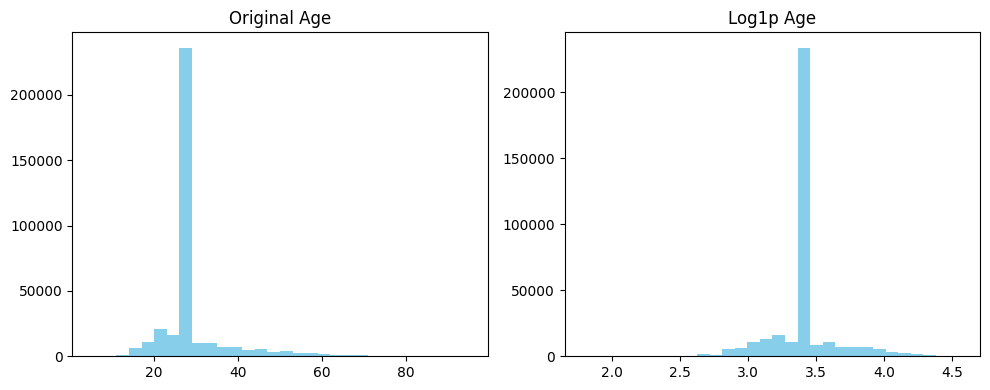

In [ ]:
# create log feature
df['Age_log'] = np.log1p(df['Age'])

# visualize BEFORE vs AFTER
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(df_original['Age'], bins=30,color='skyblue')
plt.title("Original Age")

plt.subplot(1,2,2)
plt.hist(df['Age_log'], bins=30,color='skyblue')
plt.title("Log1p Age")

plt.tight_layout()
plt.show()

In [ ]:
# Scaled one column because we don't are not going to focus on the rest so one is enough.
scaler = StandardScaler()
df['Age_log'] = scaler.fit_transform(df[['Age_log']])
df.head()
df.isna().sum()

,0
Age,0
Sex,0
BodyweightKg,0
TotalKg,0
Equipment_Raw,0
Equipment_Single-ply,0
Equipment_Straps,0
Equipment_Wraps,0
Age_Weight_Ratio,0
Age_Bodyweight_Interaction,0


In [ ]:
# 1. Define the age boundaries (bins)
# Ranges: 0-23 (Junior), 23-40 (Adult/Open), 40-100 (Mature/Master)
# Feature: AgeGroup (Binned Age)
# Why: Age doesn't affect strength linearly. A 20-year-old is gaining
# muscle fast, a 30-year-old is at their peak, and a 60-year-old is
# maintaining. Binning helps the model treat these life stages
# as distinct categories with different 'strength potentials.'
bins = [0, 23, 40, 100]

# 2. Define the labels for these groups
labels = ['Junior', 'Adult', 'Mature']

# 3. Create the new Binned Column
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

# 4.Convert to One-Hot Encoding for the model
# Since models need numbers, not words, we turn these into 0 and 1 columns
df = pd.get_dummies(df, columns=['AgeGroup'], prefix='AgeGroup', dtype=int)

# Let's see the result
df.head()

,Age,Sex,BodyweightKg,TotalKg,Equipment_Raw,Equipment_Single-ply,Equipment_Straps,Equipment_Wraps,Age_Weight_Ratio,Age_Bodyweight_Interaction,Is_Heavyweight,Using_Equipment,Heavyweight_Gear_Boost,Age_log,AgeGroup_Junior,AgeGroup_Adult,AgeGroup_Mature
0,47,0,59.60,138.35,0,0,0,1,0.788591,2801.20,0,1,0,2.127600,0,0,1
1,42,0,58.51,401.42,0,1,0,0,0.717826,2457.42,0,1,0,1.647680,0,0,1
2,42,0,58.51,95.25,1,0,0,0,0.717826,2457.42,0,0,0,1.647680,0,0,1
3,18,0,63.68,122.47,1,0,0,0,0.282663,1146.24,0,0,0,-1.915747,1,0,0
4,28,0,62.41,392.36,0,0,0,1,0.448646,1747.48,0,1,0,-0.070875,0,1,0


In [ ]:
# 1. Define your list of engineered features
# (These are the ones we created in the last few steps)
engineered_cols = [
    'Age_log', 'Age_Weight_Ratio', 'Age_Bodyweight_Interaction',
    'AgeGroup_Junior', 'AgeGroup_Adult', 'AgeGroup_Mature',
    'Heavyweight_Gear_Boost' ]

# Filter engineered_cols to only include columns actually present in df
present_engineered_cols = [col for col in engineered_cols if col in df.columns]

# Check if any engineered features are left
if not present_engineered_cols:
    print("Warning: No engineered features found in the DataFrame to compute correlation for.")
else:
    # 2. Compute Correlation ONLY for these features
    eng_corr_matrix = df[present_engineered_cols].corr().abs()

    # 3. Use the Upper Triangle to find "twins"
    upper = eng_corr_matrix.where(np.triu(np.ones(eng_corr_matrix.shape), k=1).astype(bool))

    # 4. Find features to drop (r > 0.95)
    eng_to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]

    # 5. Drop only the redundant ENGINEERED features
    df.drop(columns=eng_to_drop, inplace=True)

    print(f"Dropped redundant engineered features: {eng_to_drop}")
    print(f"Remaining Engineered Features: {[c for c in present_engineered_cols if c not in eng_to_drop]}")
# Feature: Targeted Redundancy Removal
# Why: We only check engineered features for redundancy. Original
# variables (Age, Sex, Weight) are kept as 'Ground Truth,' while
# engineered features are filtered to ensure they add unique value
# without introducing multicollinearity (r > 0.95).
# So basically, we have no redundant features good sign

Dropped redundant engineered features: []
Remaining Engineered Features: ['Age_log', 'Age_Weight_Ratio', 'Age_Bodyweight_Interaction', 'AgeGroup_Junior', 'AgeGroup_Adult', 'AgeGroup_Mature', 'Heavyweight_Gear_Boost']


In [ ]:
df.to_csv('/content/drive/MyDrive/openpowerlifting_cleaned&features (1).csv',index=False)